## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [1]:
import ray
from ray import train, tune
import numpy as np
from matplotlib import pyplot as plt

In [2]:
def generateBWParameters(samples=1, M_range=[1.0,8.0], gamma_range=[0.2,1.5],A_range=[0.3,2.0],peak_number_range=[1,4],seed=None):
    parameters = []
    rng = np.random.default_rng(seed=seed)
    for i in range(samples):
        peak_number = rng.integers(peak_number_range[0],peak_number_range[1])
        M = rng.uniform(M_range[0],M_range[1],peak_number)
        gamma = rng.uniform(gamma_range[0],gamma_range[1],peak_number)
        A = rng.uniform(A_range[0],A_range[1],peak_number)
        paramset=np.array([A,gamma,M])
        parameters.append(paramset)
    return parameters

In [3]:
omega = np.linspace(0,19.96,500)
del_omega = omega[1]-omega[0]
seed_tuning = 1


In [4]:
def rhoOmega_offset(rho_true,rho_pred,range=3):
    return np.sum(np.abs(rho_true[:range]-rho_pred[:range]))/range

def rhoOmega_offsetRelative(rho_true,rho_pred,range=3):
    return np.sum(np.abs(rho_true[:range]-np.squeeze(rho_pred)[:range])/rho_true[:range])/range

In [5]:
mean_noise=0#3e-2
num_samples = 30
num_rho = 15
sample_noise=3e-2
seed=0
learning_rate=1e-5
error_weighting=True
error_weighting_string= "error_weighting" if error_weighting else "no_error_weighting"

def train_NN_multifit(config):
    import physicsHelper
    import models
    import lossCalculator
    import correlator
    import tensorflow as tf
    


    BWparams=generateBWParameters(num_rho,seed=seed_tuning)
    BWFuns = []
    BWFunsOverOmega = []

    for p in BWparams:
        # print(p)
        mi = p[2]
        gammai = p[1]
        ai = p[0]
        peak_number = len(mi)
        BWFuns.append(physicsHelper.BWfun(ai,gammai,mi,omega))
        BWFunsOverOmega.append(physicsHelper.BWfunOverOmega(ai,gammai,mi,omega))
        plt.plot(omega,physicsHelper.BWfun(ai,gammai,mi,omega))
    plt.xlim(0,10)


    total_metric=0

    for rhoOmega_true,rho_true in zip(BWFunsOverOmega,BWFuns):
        x = np.linspace(0,19.2+0,25)
        del_xi = x[1]-x[0]

        kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
        klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)


        Dxi = correlator.Di(kl_ker_Pos,rho_true,del_omega)
        noisy_dxi_tensor, base_noisy_Dxi, custom_std = correlator.generateNoisyCorrelatorEnsemble(Dxi,x,sample_noise,num_samples,mean_noise=mean_noise, seed=1)


        target_output = tf.constant(base_noisy_Dxi, dtype=tf.float32)
        target_output=noisy_dxi_tensor
        if error_weighting:
            gauss_width = custom_std
        else:
            gauss_width = np.ones(len(x))
        kern=klW_ker_Pos
        constant_input = tf.constant([[1.0]], dtype=tf.float32) #NN
        
        model = models.SpectralNN(num_output_nodes=500, width=config["width"], depth=config["depth"])
        lossCalc=lossCalculator.LossCalculatorHyperTuning(model=model,
                                                y_true=target_output,
                                                kernel=kern,
                                                delomega=del_omega,
                                                x=constant_input,
                                                std=gauss_width,
                                                lambda_s_func_warmup=lambda x:config["lambda_s_warmup"],
                                                lambda_s_func=lambda x:config["lambda_s"],
                                                lambda_l2_func_warmup=lambda x:config["lambda_l2_warmup"],
                                                lambda_l2_func=lambda x:config["lambda_l2"]
                                                )
        # Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
        trainer=models.networkTrainer(model,optimizer,lossCalc)
        total_loss_history_warmup,loss_history_warmup=trainer.train(config["warmup_epochs"],warmup=True,verbose=True)

        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate) #notice the lower learning rate
        trainer.optimizer=optimizer
        total_loss_history,loss_history=trainer.train(config["train_epochs"],warmup=False,verbose=True)
        rho_pred=model(constant_input)
        total_metric+=rhoOmega_offsetRelative(rhoOmega_true,rho_pred,range=2)

    return total_metric/num_rho

In [6]:
search_space = { 
    "lambda_s_warmup": 1.0e-2,#tune.loguniform(1.0e-2, 1.0e-1),
    "lambda_l2_warmup": 1.0e-4,#tune.loguniform(1.0e-4, 1.0e-3),
    "lambda_s": tune.loguniform(1.0e-7, 1.0e-3),
    "lambda_l2": tune.loguniform(1.0e-10, 1.0e-6),
    "warmup_epochs": 1000,
    "width": 64,
    "depth": 3,
    "train_epochs": 30000
}

In [7]:
search_space = { 
    "lambda_s_warmup": 1.0e-2,#tune.loguniform(1.0e-2, 1.0e-1),
    "lambda_l2_warmup": 1.0e-4,#tune.loguniform(1.0e-4, 1.0e-3),
    "lambda_s": tune.grid_search([1.0e-6, 1.0e-5, 1.0e-4, 1.0e-3, 1.0e-2, 1.0e-1, 1.0]),
    "lambda_l2": tune.grid_search([1.0e-9, 1.0e-8, 1.0e-7]),
    "warmup_epochs": 1000,
    "width": 64,
    "depth": 3,
    "train_epochs": 30000
}

In [8]:
from pathlib import Path
run_name=error_weighting_string+"_seed_"+str(seed)+"sample_noise_"+str(sample_noise)+"_mean_noise_"+str(mean_noise)+"_lr_"+str(learning_rate)
ray.shutdown()
ray.init(num_cpus=24)
trainable_with_resources = tune.with_resources(train_NN_multifit, {"cpu": 1})
tuner = tune.Tuner(trainable_with_resources,
                    param_space=search_space,
                    tune_config=tune.TuneConfig(num_samples=1),
                    run_config=train.RunConfig(storage_path=Path("tuning_results/").resolve(),name=run_name)) 

2025-01-10 15:12:16,239	INFO worker.py:1821 -- Started a local Ray instance.


In [9]:
results = tuner.fit()

(train_NN_multifit pid=77985) 2025-01-10 15:12:19.505394: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
(train_NN_multifit pid=77985) 2025-01-10 15:12:19.506019: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
(train_NN_multifit pid=77985) 2025-01-10 15:12:19.508245: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
(train_NN_multifit pid=77985) 2025-01-10 15:12:19.515526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(train_NN_multifit pid=77935) WARNING: All log messages before absl::InitializeL

(train_NN_multifit pid=77908) Training for 1000 epochs
(train_NN_multifit pid=77908) Epoch 0, Loss: 746.8477783203125
(train_NN_multifit pid=77922) Training for 1000 epochs [repeated 20x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(train_NN_multifit pid=77980) Epoch 200, Loss: 0.026965899392962456 [repeated 60x across cluster]
(train_NN_multifit pid=77965) Epoch 500, Loss: 0.008869888260960579 [repeated 41x across cluster]
(train_NN_multifit pid=77908) Epoch 700, Loss: 0.0043566576205194 [repeated 43x across cluster]
(train_NN_multifit pid=77907) Epoch 800, Loss: 0.007718854118138552 [repeated 39x across cluster]
(train_NN_multifit pid=77945) Training took 23.183658123016357 seconds
(train_NN_multifit pid=77945) Training for 30000 epochs
(train_NN_multifit pid=77922) Epoch 900, Loss: 0.004864242859184742

2025-01-10 18:33:34,732	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/lpannullo/professional/projects/SpectralFunctionWithML/tuning_results/error_weighting_seed_0sample_noise_0.03_mean_noise_0_lr_1e-05' in 0.0035s.
2025-01-10 18:33:34,735	INFO tune.py:1041 -- Total run time: 12077.30 seconds (12077.28 seconds for the tuning loop).


In [10]:
!tensorboard --logdir tuning_results

2025-01-13 16:19:59.007253: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-13 16:19:59.007577: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-13 16:19:59.009323: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-13 16:19:59.014400: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736781599.023014  329151 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736781599.02

In [15]:
print(results.get_best_result(metric="_metric", mode="min").config)

{'lambda_s_warmup': 0.01, 'lambda_l2_warmup': 0.0001, 'lambda_s': 6.9877915950256485e-06, 'lambda_l2': 2.3667835227018086e-07, 'warmup_epochs': 1000, 'width': 64, 'depth': 3, 'train_epochs': 30000}


Text(0, 0.5, 'lambda_l2')

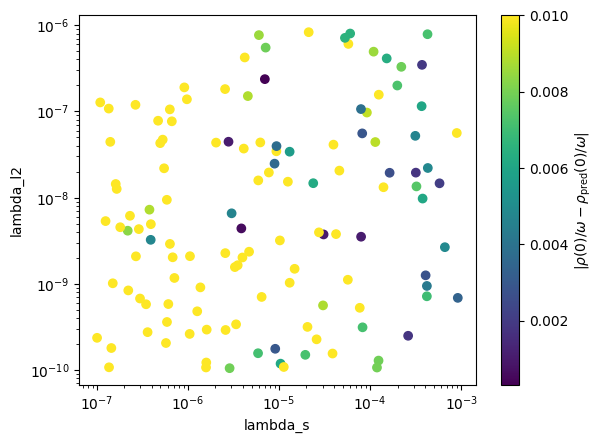

In [14]:
data=[]

for result in results:
   data.append([result.config["lambda_s"],result.config["lambda_l2"],result.metrics["_metric"]])

data=np.array(data)
#plot data
fig, ax = plt.subplots()
scat=ax.scatter(data[:,0],data[:,1],c=np.abs(data[:,2]),cmap='viridis',vmax=0.01)

#colorbar
cbar = plt.colorbar(scat,label=r'$|\rho(0)/\omega - \rho_\mathrm{pred}(0)/\omega|$')


plt.xscale('log')
plt.yscale('log')

plt.xlabel('lambda_s')
plt.ylabel('lambda_l2')



Text(0, 0.5, 'lambda_l2')

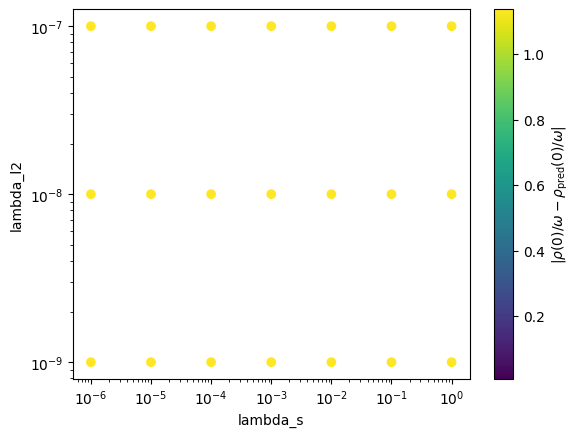

In [11]:
data=[]

for result in results:
   data.append([result.config["lambda_s"],result.config["lambda_l2"],result.metrics["_metric"]])

data=np.array(data)
#plot data
fig, ax = plt.subplots()
scat=ax.scatter(data[:,0],data[:,1],c=np.abs(data[:,2]),cmap='viridis',vmax=0.01)

#colorbar
cbar = plt.colorbar(scat,label=r'$|\rho(0)/\omega - \rho_\mathrm{pred}(0)/\omega|$')


plt.xscale('log')
plt.yscale('log')

plt.xlabel('lambda_s')
plt.ylabel('lambda_l2')



In [13]:
data

array([[1.00000000e-06, 1.00000000e-09, 7.41185600e+00],
       [1.00000000e-06, 1.00000000e-08, 6.50713412e+00],
       [1.00000000e-06, 1.00000000e-07, 1.02049374e+01],
       [1.00000000e-05, 1.00000000e-09, 4.48431573e+00],
       [1.00000000e-05, 1.00000000e-08, 4.73805951e+00],
       [1.00000000e-05, 1.00000000e-07, 5.21769694e+00],
       [1.00000000e-04, 1.00000000e-09, 2.90842507e+00],
       [1.00000000e-04, 1.00000000e-08, 2.81616398e+00],
       [1.00000000e-04, 1.00000000e-07, 3.03268554e+00],
       [1.00000000e-03, 1.00000000e-09, 1.84331768e+00],
       [1.00000000e-03, 1.00000000e-08, 1.84276403e+00],
       [1.00000000e-03, 1.00000000e-07, 1.91367806e+00],
       [1.00000000e-02, 1.00000000e-09, 1.25445642e+00],
       [1.00000000e-02, 1.00000000e-08, 1.24933802e+00],
       [1.00000000e-02, 1.00000000e-07, 1.25301992e+00],
       [1.00000000e-01, 1.00000000e-09, 1.13615286e+00],
       [1.00000000e-01, 1.00000000e-08, 1.13625636e+00],
       [1.00000000e-01, 1.00000